In [1]:
## Get the Data
## EDA
## Data cleaning
## Feature Engineering
## Implement Linear Regression model
## Make My Linear Regression model
## Implement My Linear Regression model

In [2]:
## Data options
# Insurance Charges Dataset (numerical)    https://www.kaggle.com/datasets/kanzariachref/medical-insurance-cost-dataset
# Energy Efficiency Dataset (numerical)    https://www.kaggle.com/datasets/ujjwalchowdhury/energy-efficiency-data-set
# Stock Market Dataset (numerical)         https://www.kaggle.com/datasets/paultimothymooney/stock-market-data
# Advertising Dataset (numerical)          https://www.kaggle.com/datasets/ashydv/advertising-dataset
# Customer Churn Dataset                   https://www.kaggle.com/datasets/muhammadshahidazeem/customer-churn-dataset
# Student Performance Dataset              https://www.kaggle.com/datasets/nikhil7280/student-performance-multiple-linear-regression
# Vehicle dataset                          https://www.kaggle.com/datasets/nehalbirla/vehicle-dataset-from-cardekho

## 1-Search for Data and Select one and import it
Selected Data set ======> Student Performance Dataset

In [2]:
# import essential libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('Student_Performance.csv')
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


## 2- EDA

In [4]:
df.shape

(10000, 6)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [6]:
df.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [9]:
print(df.duplicated().sum())
df[df.duplicated()==True]


127


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
915,9,52,No,5,9,48.0
1477,7,61,Yes,6,8,54.0
1601,5,99,No,7,5,89.0
1786,2,62,Yes,9,4,40.0
2026,5,87,Yes,6,7,74.0
...,...,...,...,...,...,...
9644,4,91,Yes,4,3,71.0
9940,8,95,No,5,2,90.0
9954,6,97,No,8,7,92.0
9966,1,41,No,7,3,12.0


In [16]:
df['Performance Index'].value_counts()

Performance Index
67.0     187
45.0     185
49.0     181
56.0     181
40.0     180
        ... 
14.0       7
99.0       6
11.0       5
100.0      3
10.0       1
Name: count, Length: 91, dtype: int64

<Axes: xlabel='Performance Index', ylabel='Count'>

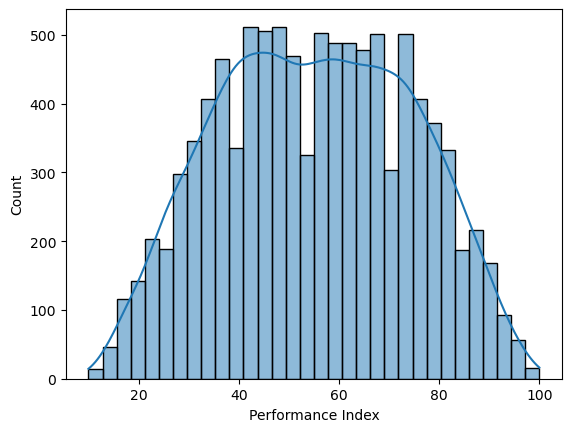

In [18]:
sns.histplot(df['Performance Index'], kde= True)

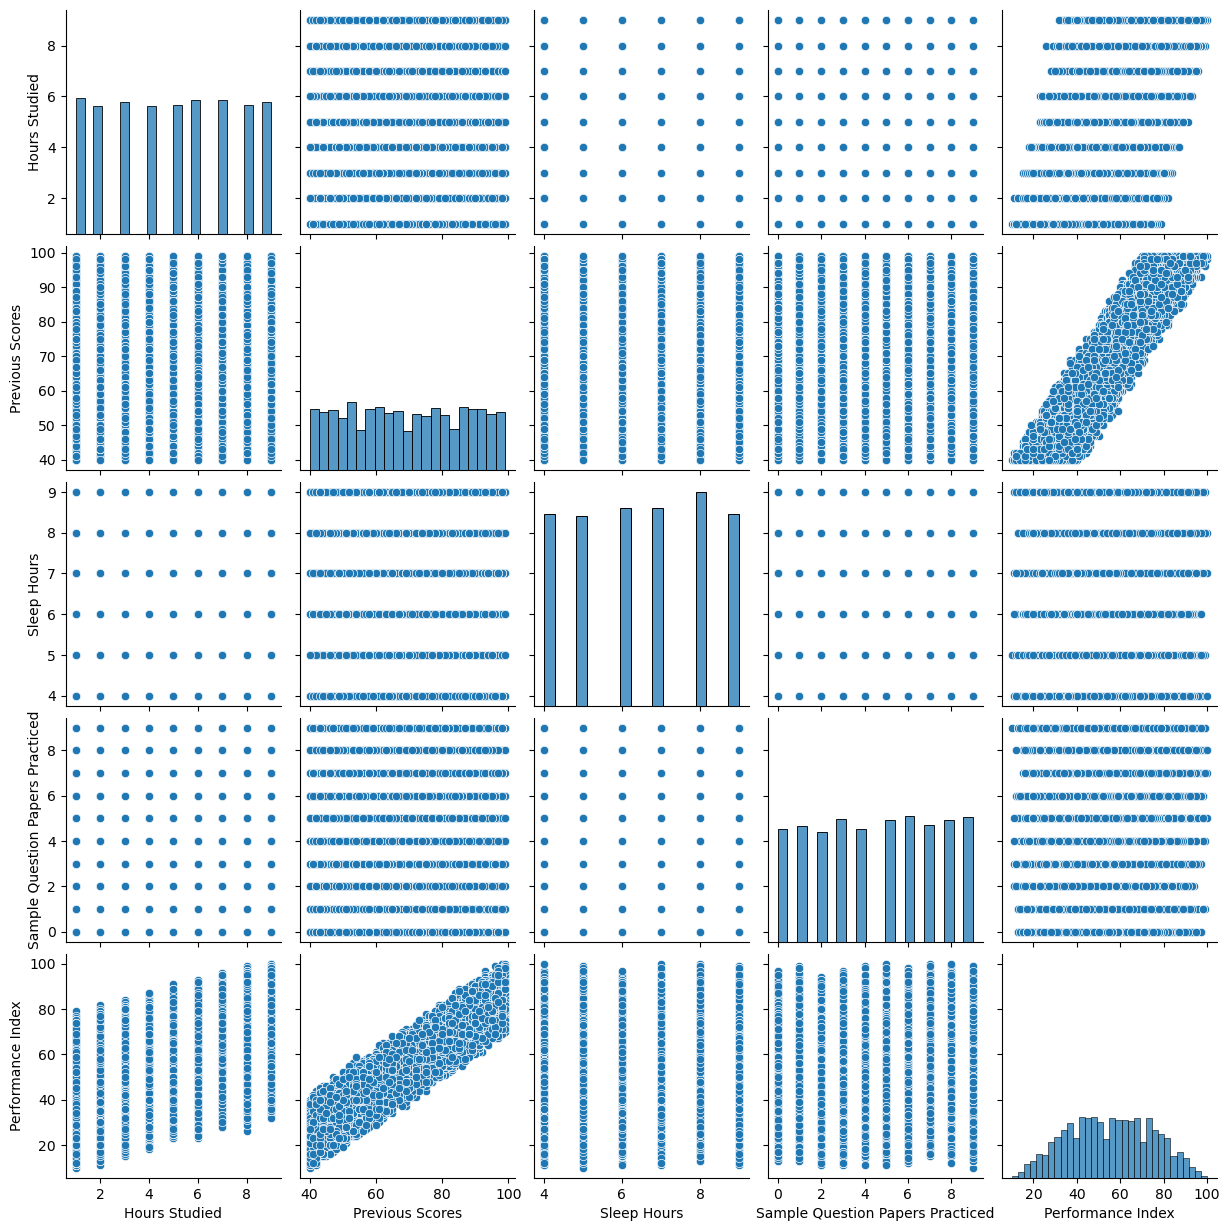

In [19]:
sns.pairplot(df)

In [33]:
df_numeric = df.drop('Extracurricular Activities', axis=1)
len(df_numeric.columns[:-1])

4

In [21]:
df.columns

Index(['Hours Studied', 'Previous Scores', 'Extracurricular Activities',
       'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index'],
      dtype='object')

<Axes: >

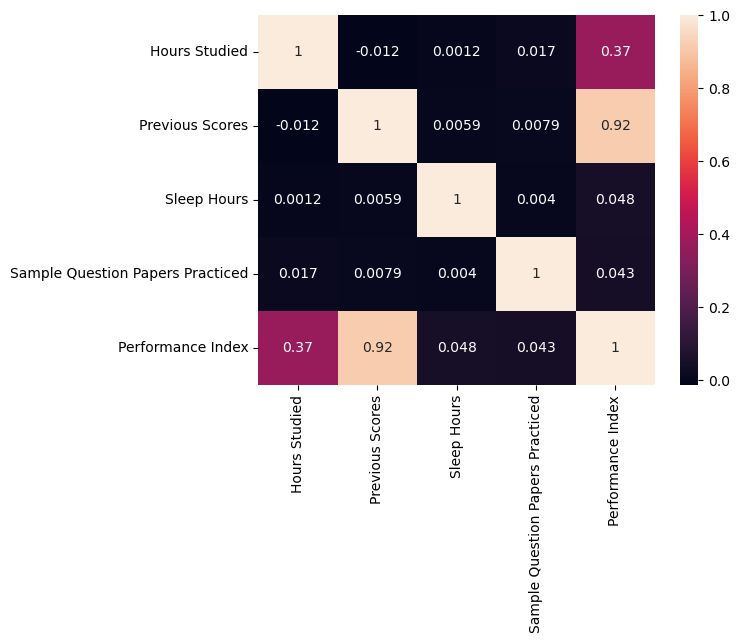

In [24]:
sns.heatmap(df.drop('Extracurricular Activities', axis=1).corr(), annot=True)

Index(['Hours Studied', 'Previous Scores', 'Extracurricular Activities',
       'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index'],
      dtype='object')


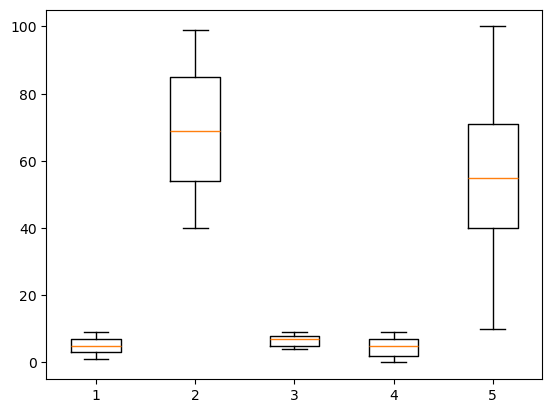

In [40]:
print(df.columns)
plt.boxplot(df.drop('Extracurricular Activities', axis=1))
plt.show();

## Data Cleaning

In [72]:
## no misssing values
## there are duplicates but i will try to leave them
## no outliers
## no data correction

In [73]:
df_copy['Extracurricular Activities'].unique()

array(['Yes', 'No'], dtype=object)

## 3- Feature Engineering

In [59]:
# no need for scaling

In [51]:
## Encoding
from sklearn.preprocessing import OrdinalEncoder
encoder = OrdinalEncoder()
encoded = encoder.fit_transform(df[['Extracurricular Activities']])
type(encoded)


numpy.ndarray

In [53]:
encoded_df = pd.DataFrame(encoded, columns= encoder.get_feature_names_out())
encoded_df

,Extracurricular Activities
0,1.0
1,0.0
2,1.0
3,1.0
4,0.0
...,...
9995,1.0
9996,1.0
9997,1.0
9998,1.0


In [57]:
#df = df.drop('Extracurricular Activities', axis=1)
df = pd.concat([df,encoded_df], axis=1)

In [58]:
df

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index,Extracurricular Activities
0,7,99,9,1,91.0,1.0
1,4,82,4,2,65.0,0.0
2,8,51,7,2,45.0,1.0
3,5,52,5,2,36.0,1.0
4,7,75,8,5,66.0,0.0
...,...,...,...,...,...,...
9995,1,49,4,2,23.0,1.0
9996,7,64,8,5,58.0,1.0
9997,6,83,8,5,74.0,1.0
9998,9,97,7,0,95.0,1.0


In [74]:
encoder.transform([['Yes']])

C:\Users\Mostafa\Desktop\Learing\env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but OrdinalEncoder was fitted with feature names
  warnings.warn(


array([[1.]])

## 4- Splitting Data

In [118]:
## Splitting Input and Output
X = df.drop('Performance Index', axis=1)
y = df[['Performance Index']]
X.head()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Extracurricular Activities
0,7,99,9,1,1.0
1,4,82,4,2,0.0
2,8,51,7,2,1.0
3,5,52,5,2,1.0
4,7,75,8,5,0.0


In [119]:
y.head()

,Performance Index
0,91.0
1,65.0
2,45.0
3,36.0
4,66.0


In [163]:
## Splitting into Train and Test Sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

## 5- Modeling (Linear Regression)

In [121]:
from sklearn.linear_model import LinearRegression

In [122]:
model_LR = LinearRegression()
model_LR.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


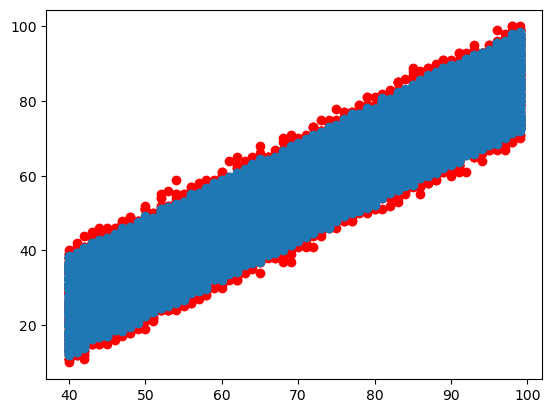

In [142]:
plt.scatter(X_train.iloc[:,1], y_train,c='red')
plt.scatter(X_train.iloc[:,1], model_LR.predict(X_train))
plt.show()

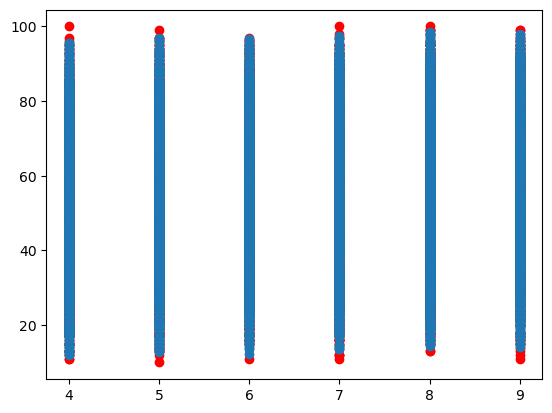

In [143]:
plt.scatter(X_train.iloc[:,2], y_train,c='red')
plt.scatter(X_train.iloc[:,2], model_LR.predict(X_train))
plt.show()

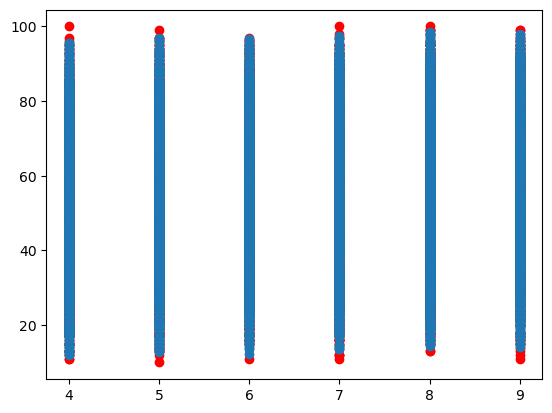

In [144]:
plt.scatter(X_train.iloc[:,2], y_train,c='red')
plt.scatter(X_train.iloc[:,2], model_LR.predict(X_train))
plt.show()

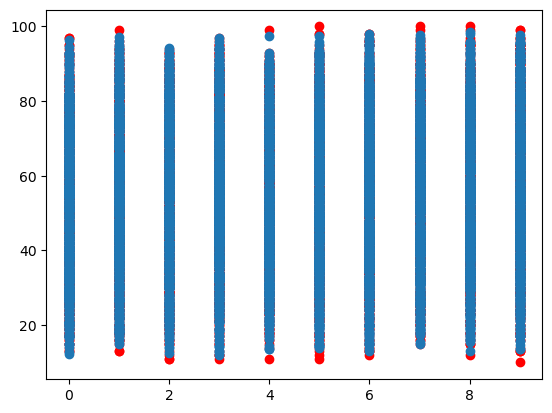

In [145]:
plt.scatter(X_train.iloc[:,3], y_train,c='red')
plt.scatter(X_train.iloc[:,3], model_LR.predict(X_train))
plt.show()

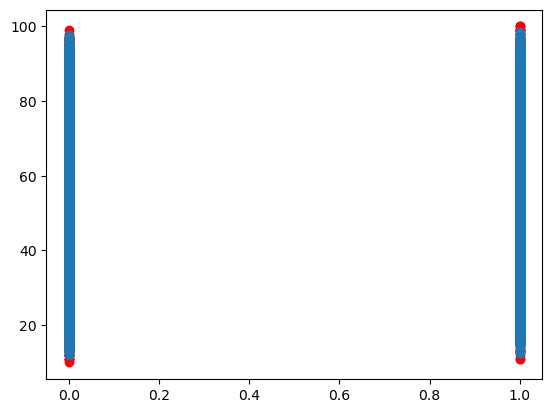

In [141]:
plt.scatter(X_train.iloc[:,4], y_train,c='red')
plt.scatter(X_train.iloc[:,4], model_LR.predict(X_train))
plt.show()

In [131]:
y_pred = model_LR.predict(X_test)
y_pred

array([[96.26726432],
       [83.24786316],
       [38.6483463 ],
       ...,
       [45.63209079],
       [80.94742723],
       [50.03037556]], shape=(2000, 1))

In [132]:
y_test

,Performance Index
7249,96.0
9625,79.0
3242,36.0
5617,44.0
3266,78.0
...,...
9330,46.0
327,29.0
598,48.0
2080,79.0


In [167]:
model_LR.coef_, X.columns

(array([[2.85194564, 1.01955236, 0.48156149, 0.19319258, 0.59389505]]),
 Index(['Hours Studied', 'Previous Scores', 'Sleep Hours',
        'Sample Question Papers Practiced', 'Extracurricular Activities'],
       dtype='object'))

In [224]:
df_studied_hours=df[df['Hours Studied']==4]
df_high_performance = df_studied_hours[df_studied_hours['Performance Index']>=85]
#df_high_performance = df_high_performance[df_studied_hours['Sleep Hours']>=6]
df_high_performance = df_high_performance[df_high_performance['Extracurricular Activities']==1]
#df_high_performance = df_high_performance[df_high_performance['Previous Scores']==1]
#df_high_performance = df_high_performance[df_high_performance['Sample Question Papers Practiced']1]
df_high_performance.sort_values(by='Sample Question Papers Practiced')

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index,Extracurricular Activities
6831,4,97,9,3,85.0,1.0
337,4,99,8,5,87.0,1.0
5551,4,98,8,6,86.0,1.0


In [225]:
good_rows_1hr = df.loc[[373,3870,7840,3470,2316,128]]
good_rows_2hr = df.loc[[8633,2719,8996,579]]
good_rows_3hr = df.loc[[9311,9242,4399]]
good_row_4hr = df.loc[[6831]]

In [206]:
df_high_performance.sort_values(by='Performance Index')

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index,Extracurricular Activities
2989,1,94,8,6,70.0,1.0
7448,1,94,6,4,70.0,1.0
3870,1,91,9,7,71.0,1.0
128,1,97,8,0,71.0,1.0
5454,1,94,6,3,71.0,1.0
7840,1,92,9,9,71.0,1.0
1735,1,96,7,9,71.0,1.0
4263,1,97,6,4,72.0,1.0
6497,1,95,6,6,73.0,1.0
2636,1,97,8,7,73.0,1.0


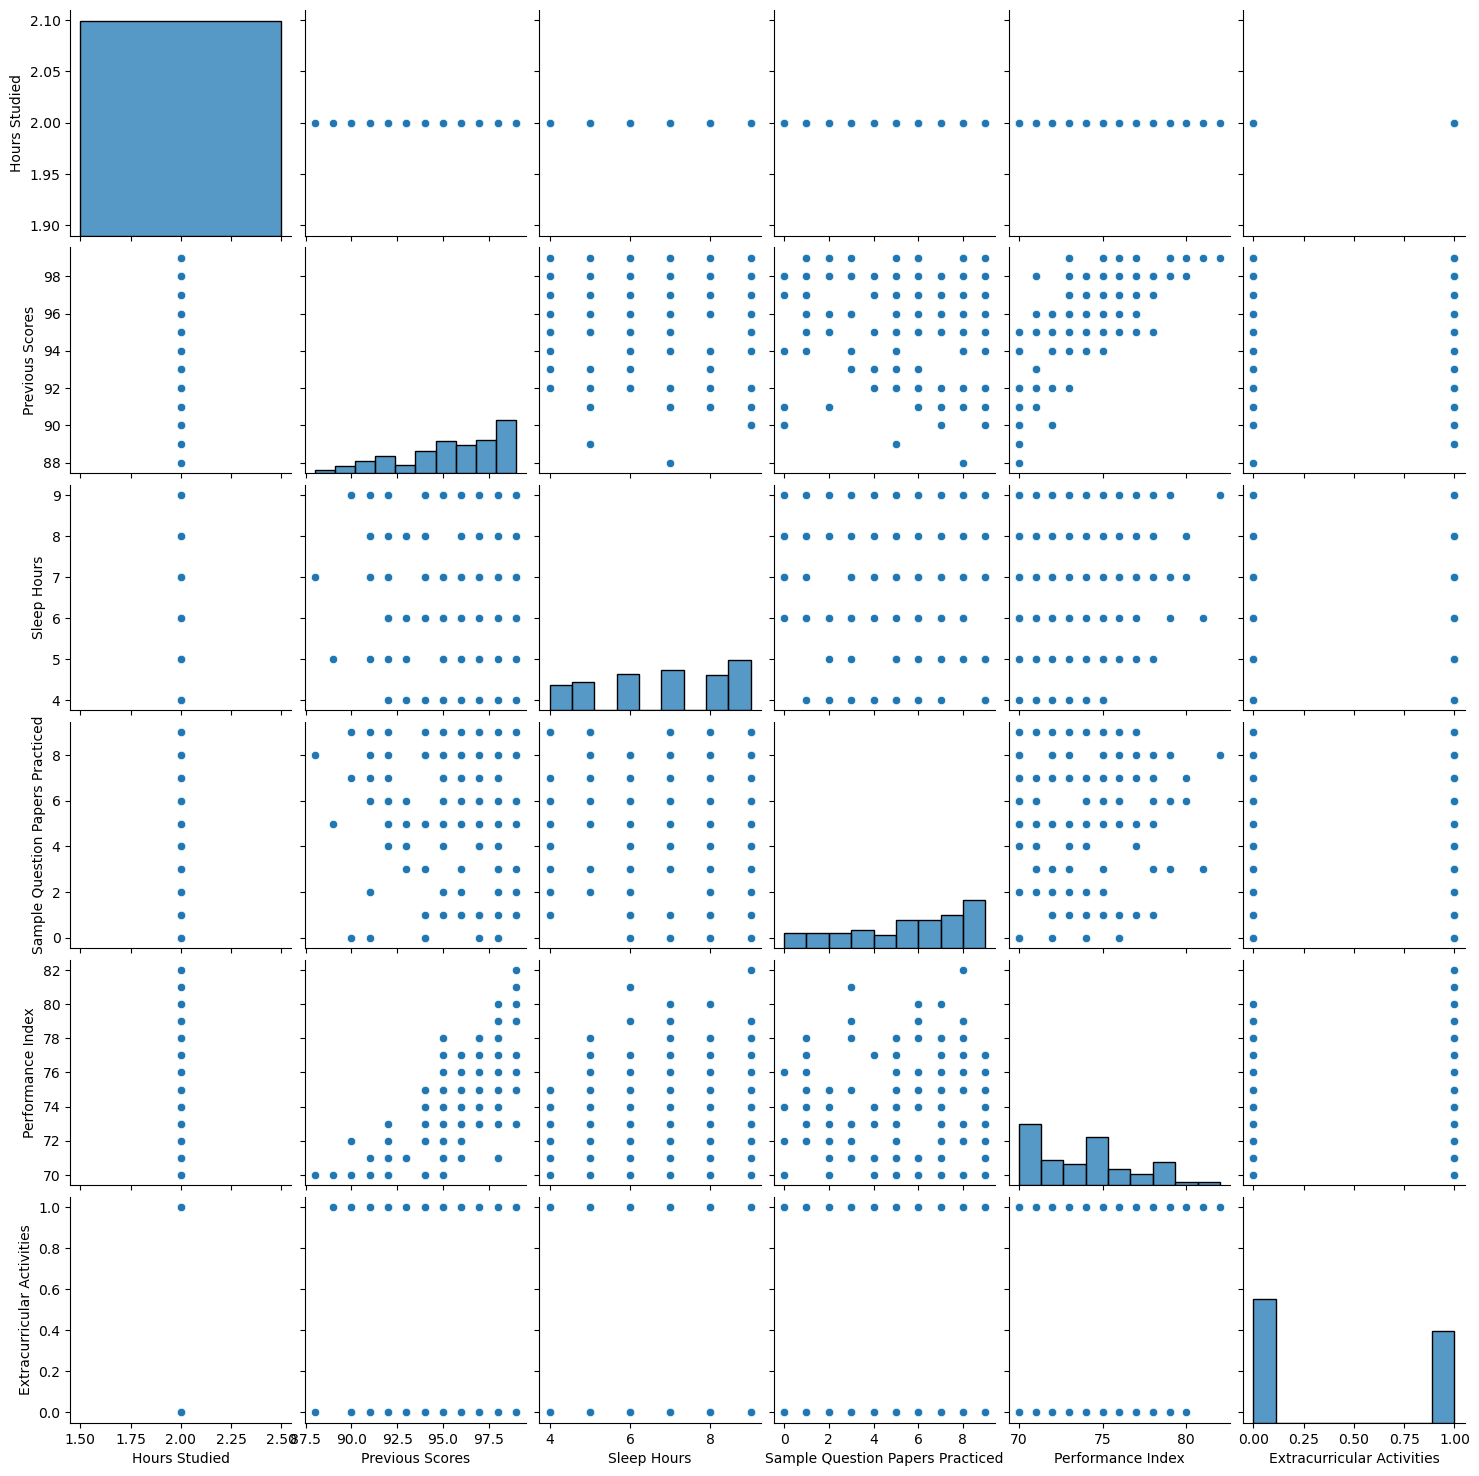

In [180]:
sns.pairplot(df_high_performance)

## 6- Evaluation

In [136]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

In [134]:
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print('MSE',mse)
print('MAE',mae)
print('RMSE',rmse)

MSE 4.114911510188267
MAE 1.6112256743238462
RMSE 2.0285244662533075


In [138]:
r_squared = r2_score(y_test,y_pred)
r_squared

0.9887136104949643

In [139]:
adj_r_squared = 1 - (1-r_squared)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)
adj_r_squared

0.9886853096185726

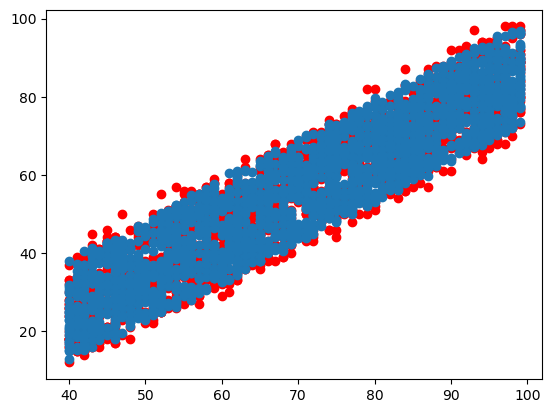

In [150]:
plt.scatter(X_test.iloc[:,1], y_test,c='red')
plt.scatter(X_test.iloc[:,1], y_pred)
plt.show()

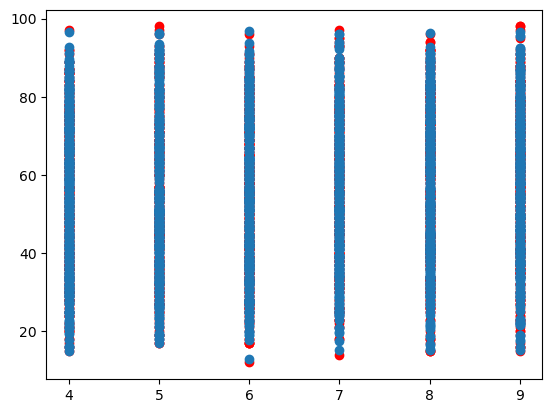

In [151]:
plt.scatter(X_test.iloc[:,2], y_test,c='red')
plt.scatter(X_test.iloc[:,2], y_pred)
plt.show()

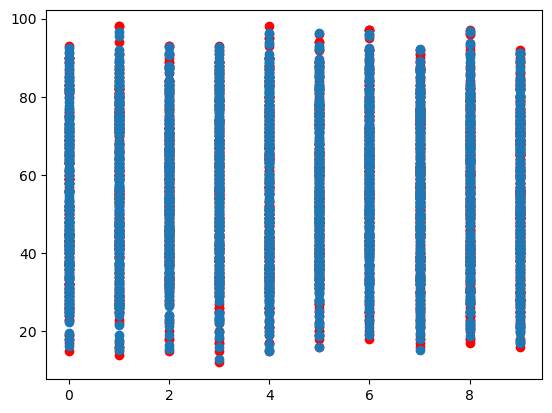

In [152]:
plt.scatter(X_test.iloc[:,3], y_test,c='red')
plt.scatter(X_test.iloc[:,3], y_pred)
plt.show()

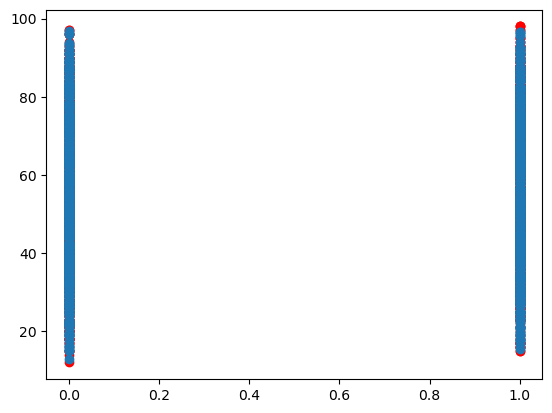

In [153]:
plt.scatter(X_test.iloc[:,4], y_test,c='red')
plt.scatter(X_test.iloc[:,4], y_pred)
plt.show()

## 7- Trying other thing in the same model

## 8- Tring other Model

In [155]:
import statsmodels.api as sm

In [156]:
model=sm.OLS(y_train,X_train).fit()

In [157]:
prediction=model.predict(X_test)
print(prediction)

7249    86.523831
9625    72.580666
3242    38.871592
5617    39.204476
3266    79.530227
          ...    
9330    45.758898
327     33.530487
598     46.363853
2080    73.234984
6399    45.577000
Length: 2000, dtype: float64


In [158]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:      Performance Index   R-squared (uncentered):                   0.990
Model:                            OLS   Adj. R-squared (uncentered):              0.990
Method:                 Least Squares   F-statistic:                          1.586e+05
Date:                Fri, 05 Sep 2025   Prob (F-statistic):                        0.00
Time:                        12:47:25   Log-Likelihood:                         -25462.
No. Observations:                8000   AIC:                                  5.093e+04
Df Residuals:                    7995   BIC:                                  5.097e+04
Df Model:                           5                                                  
Covariance Type:            nonrobust                                                  
                                       coef    std err          t      P>|t|      [0.025      0.975]
-------------------

In [160]:
mse=mean_squared_error(y_test,prediction)
mae=mean_absolute_error(y_test,prediction)
rmse=np.sqrt(mse)
print('MSE',mse)
print('MAE',mae)
print('RMSE',rmse)

MSE 33.794759018937555
MAE 4.757310274141075
RMSE 5.813325985951377


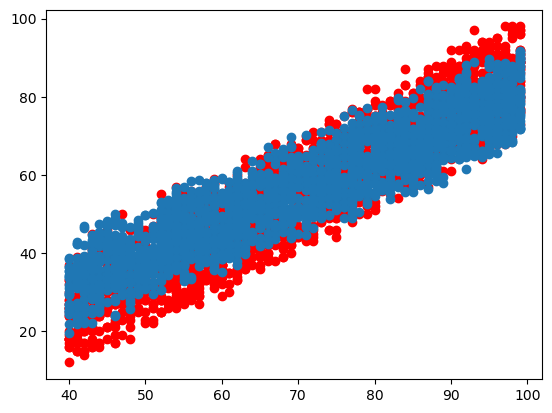

In [161]:
plt.scatter(X_test.iloc[:,1], y_test,c='red')
plt.scatter(X_test.iloc[:,1], prediction)
plt.show()

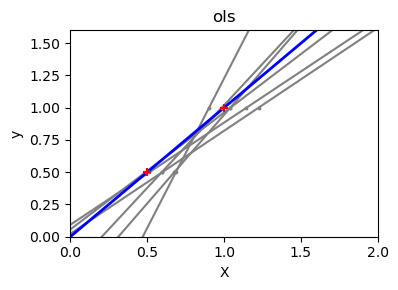

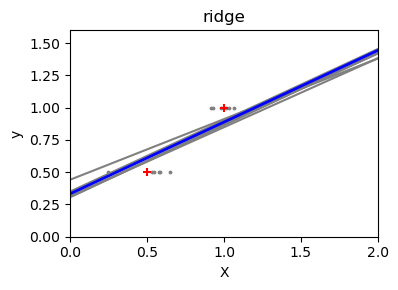

In [165]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn import linear_model

X_train = np.c_[0.5, 1].T
y_train = [0.5, 1]
X_test = np.c_[0, 2].T

np.random.seed(0)

classifiers = dict(
    ols=linear_model.LinearRegression(), ridge=linear_model.Ridge(alpha=0.1)
)

for name, clf in classifiers.items():
    fig, ax = plt.subplots(figsize=(4, 3))

    for _ in range(6):
        this_X = 0.1 * np.random.normal(size=(2, 1)) + X_train
        clf.fit(this_X, y_train)

        ax.plot(X_test, clf.predict(X_test), color="gray")
        ax.scatter(this_X, y_train, s=3, c="gray", marker="o", zorder=10)

    clf.fit(X_train, y_train)
    ax.plot(X_test, clf.predict(X_test), linewidth=2, color="blue")
    ax.scatter(X_train, y_train, s=30, c="red", marker="+", zorder=10)

    ax.set_title(name)
    ax.set_xlim(0, 2)
    ax.set_ylim((0, 1.6))
    ax.set_xlabel("X")
    ax.set_ylabel("y")

    fig.tight_layout()

plt.show()

In [118]:
## Splitting Input and Output
X = df.drop('Performance Index', axis=1)
y = df[['Performance Index']]
X.head()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Extracurricular Activities
0,7,99,9,1,1.0
1,4,82,4,2,0.0
2,8,51,7,2,1.0
3,5,52,5,2,1.0
4,7,75,8,5,0.0


In [264]:
model_LR.predict([[2.7,99,9,3,1]])

C:\Users\Mostafa\Desktop\Learing\env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[80.00863052]])